
# Objetivo: Aprender a aplicar regresión lineal para predecir el número de bicicletas alquiladas en un día.
# Nombre: Tatiana Andrea Castellanos Castro
===================================================
#1. Introducción
===================================================

Pregunta: ¿Qué tipo de problemas se pueden resolver con regresión lineal?

R= La regresión lineal se utiliza para resolver problemas de predicción numérica, donde se busca estimar el valor de una variable continua (dependiente) a partir de una o más variables independientes.

Por ejemplo:

Predecir el precio de un iPhone según su capacidad, año y estado.

Estimar el número de bicicletas alquiladas en función de la temperatura, la hora o las condiciones climáticas.

Calcular el valor de una casa según su tamaño y ubicación.

Escribe tu respuesta aquí en un comentario.

In [1]:
#Importa el/los módulo(s) pandas as pd para usarlos en el análisis.
import pandas as pd
# Obtiene el dataset de url externa
!wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
# Lee un archivo CSV y lo carga en un DataFrame de Pandas.
bike_data = pd.read_csv("daily-bike-share.csv")

--2025-10-17 19:10:15--  https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/daily-bike-share.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48800 (48K) [text/plain]
Saving to: ‘daily-bike-share.csv’

daily-bike-share.cs 100%[===================>]  47.66K  --.-KB/s    in 0.007s  

2025-10-17 19:10:15 (6.47 MB/s) - ‘daily-bike-share.csv’ saved [48800/48800]



In [2]:
import pandas as pd
# Muestra las primeras 5 filas del dataset
display(bike_data.head())

# Muestra información general del dataset
display(bike_data.info())

# Genera una tabla con la descripción de cada campo y su significado
display(bike_data.describe())

# Pregunta: ¿Qué variable queremos predecir?
# Respuesta: La variable que queremos predecir es rentals, ya que representa el número de alquileres de bicicletas y es la variable objetivo (label) del modelo de regresión.

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  rentals     731 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 80.1+ KB


None

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,rentals
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000


In [3]:
# TRANSFORMACIÓN DE VARIABLES DE FECHA
# Convertir la columna 'dteday' a formato de fecha (datetime)
bike_data['dteday'] = pd.to_datetime(bike_data['dteday'])

# Extrae el día del mes desde la columna de fechas
bike_data['day'] = bike_data['dteday'].dt.day

# Verificar que la nueva columna se haya creado correctamente
print(" Columnas después de agregar 'day':")
print(bike_data.columns.tolist())

# Muestra las primeras 25 filas del dataset
display(bike_data[['dteday', 'day']].head(25))

 Columnas después de agregar 'day':
['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'rentals', 'day']


,dteday,day
0,2011-01-01,1
1,2011-01-02,2
2,2011-01-03,3
3,2011-01-04,4
4,2011-01-05,5
5,2011-01-06,6
6,2011-01-07,7
7,2011-01-08,8
8,2011-01-09,9
9,2011-01-10,10


#3. Preparación de datos

In [4]:
# Definir las características numéricas relevantes del dataset
features = ['season', 'mnth', 'holiday', 'weekday', 'workingday',
            'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'day']

X = bike_data[features]

# Seleccionar la variable objetivo (label)
y = bike_data['rentals']

# Mostrar estadísticas descriptivas de las variables numéricas y el objetivo
print(" Estadísticas descriptivas de las características numéricas:")
display(X.describe())

print("\n Estadísticas descriptivas de la variable objetivo (count):")
display(y.describe())

 Estadísticas descriptivas de las características numéricas:


,season,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,day
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,15.738714
std,1.110807,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,8.809949
min,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,1.000000
25%,2.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,8.000000
50%,3.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,16.000000
75%,3.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,23.000000
max,4.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,31.000000



 Estadísticas descriptivas de la variable objetivo (count):


,rentals
count,731.000000
mean,848.176471
std,686.622488
min,2.000000
25%,315.500000
50%,713.000000
75%,1096.000000
max,3410.000000


#4.Gráfica de datos

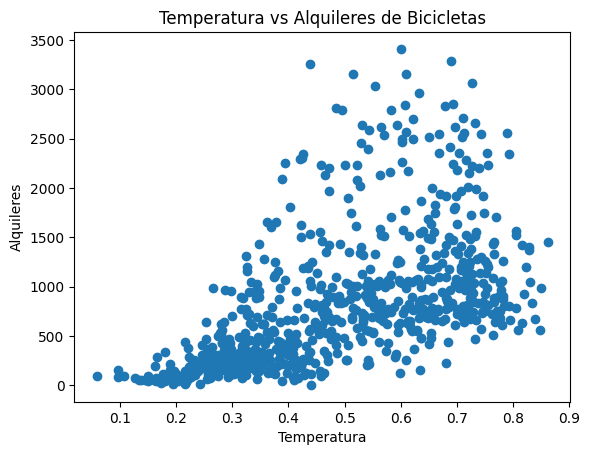

In [5]:
# TODO: Grafica una dispersión de temperatura vs rentals
import matplotlib.pyplot as plt

plt.scatter(bike_data['temp'], bike_data['rentals'])
plt.xlabel('Temperatura')
plt.ylabel('Alquileres')
plt.title('Temperatura vs Alquileres de Bicicletas')
plt.show()

# Pregunta: ¿Se observa alguna relación lineal?
# Respuesta: Sí, se observa una relación lineal positiva entre la temperatura y los alquileres de bicicletas. A medida que aumenta la temperatura, también tiende a aumentar la cantidad de bicicletas alquiladas.

# 4. División en conjuntos de entrenamiento y prueba

In [6]:
from sklearn.model_selection import train_test_split

X = bike_data[features]
y = bike_data['rentals']

# Divide los datos en entrenamiento (70%) y prueba con test_size (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Mostrar cuántas filas tiene cada conjunto
print("Filas en el conjunto de entrenamiento (X):", X_train.shape[0])
print("Filas en el conjunto de prueba (X):", X_test.shape[0])
print("Filas en el conjunto de entrenamiento (y):", y_train.shape[0])
print("Filas en el conjunto de prueba (y):", y_test.shape[0])

# Pregunta: ¿Qué pasa si usamos un test_size demasiado pequeño?
# Respuesta Si usamos un test_size demasiado pequeño, el conjunto de prueba tendría muy pocos datos, lo que dificultaría evaluar correctamente el rendimiento del modelo y podría dar resultados poco representativos.

Filas en el conjunto de entrenamiento (X): 511
Filas en el conjunto de prueba (X): 220
Filas en el conjunto de entrenamiento (y): 511
Filas en el conjunto de prueba (y): 220


# 5. Entrenamiento del modelo

In [7]:
from sklearn.linear_model import LinearRegression


# TODO: Crea y entrena el modelo
model = LinearRegression()
model.fit(X_train, y_train)


# Muestra los coeficientes βn
print("Coeficientes:", model.coef_)
# rentals=β0​+β1​⋅temp+β2​⋅atemp+β3​⋅hum+β4​⋅windspeed

# Muestra información del modelo entrenado

# Pregunta: ¿Cómo interpretas el coeficiente asociado a la temperatura?
# Respuesta: El coeficiente asociado a la temperatura indica que, al aumentar la temperatura en una unidad, el número de alquileres de bicicletas tiende a aumentar en aproximadamente 11 unidades, manteniendo las demás variables constantes. Esto sugiere una relación positiva entre la temperatura y la demanda de bicicletas.

Coeficientes: [   71.76988769   -14.62164139  -317.27443043    11.09161191
  -837.08711517   -51.21672552  2050.19665653   -84.67349495
  -532.45288286 -1220.98066016    -2.14377441]


# 6. Evaluación del modelo

MSE: 202873.55569369096


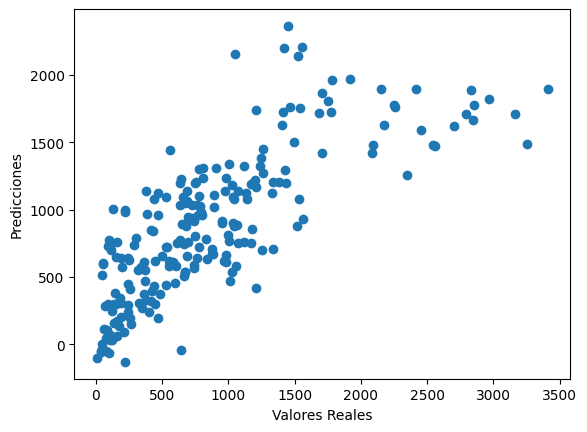

In [8]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Genera predicciones
y_pred = model.predict(X_test)


# Calcula métrica MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


# Grafica valores reales vs predichos
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.show()


# Pregunta: ¿Qué información nos da el MSE sobre la calidad del modelo?
# Respuesta: El MSE (Mean Squared Error) indica el promedio del error cuadrático entre los valores reales y los predichos. Un valor menor de MSE significa que el modelo tiene mejor precisión y comete menos errores al predecir.
# Pregunta: ¿Qué información nos da el RMSE sobre la calidad del modelo?
# Respuesta El RMSE (Root Mean Squared Error) muestra el error promedio en las mismas unidades que la variable objetivo. Cuanto menor sea el RMSE, más precisas son las predicciones del

# 7. Extensión / Retos

In [9]:
# Entrena un modelo usando solo la variable 'temp'.
# Compara los resultados con el modelo multivariable.

# Seleccionar solo la variable 'temp' como característica
X_temp = bike_data[['temp']]
y_temp = bike_data['rentals']

# Divide los datos en entrenamiento y prueba
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.3, random_state=0)

# Crea y entrena el modelo con solo la variable 'temp'
model_temp = LinearRegression()
model_temp.fit(X_train_temp, y_train_temp)

# Genera predicciones con el modelo de temperatura
y_pred_temp = model_temp.predict(X_test_temp)

# Calcula el MSE para el modelo de temperatura
mse_temp = mean_squared_error(y_test_temp, y_pred_temp)

print("MSE del modelo con múltiples variables:", mse)
print("MSE del modelo con solo temperatura:", mse_temp)


# Pregunta: ¿Cuál modelo es más preciso y por qué?
# Respuesta: El modelo con múltiples variables es más preciso porque tiene un MSE menor (202873) comparado con el modelo que usa solo la temperatura (374482). Esto significa que al incluir más variables, el modelo logra mejores predicciones al capturar más factores que influyen en los alquileres de bicicletas

MSE del modelo con múltiples variables: 202873.55569369096
MSE del modelo con solo temperatura: 374482.8022842907
